# 🧠 Claim Prediction – Data Mining & Visualization

## 1. Project Overview & Business Objective

This project focuses on developing a predictive model for detecting potentially fraudulent insurance claims. 

Fraudulent claims can result in substantial financial losses for insurance companies.

### Objective 

The goal is to analyze a structured dataset of insurance claims and build a reliable classification model.

### Business Impact

- Reduce financial losses due to fraud
- Accelerate the claims validation process
- Allocate investigative resources more efficiently
- Protect honest customers from rising premium costs


### Project Scope

- **Exploratory Data Analysis (EDA)** to uncover patterns, imbalances, and inconsistencies
- **Preprocessing and Feature Engineering** to prepare data for modeling
- **Modeling and Optimization** using machine learning techniques 
- **Interpretation & Reporting** to derive actionable insights and build a business-oriented final report


### Potential Biases in the Dataset

When working with real-world insurance claim data, several types of bias may affect the model’s performance when not handling accurate:

- **Class Imbalance**: Fraudulent claims are typically much rarer than legitimate ones, which can lead to models biased toward predicting the majority class (non-fraud).
- **Reporting Bias**: Not all fraud is detected or reported in real life. This means some claims labeled as non-fraudulent may actually be fraudulent.
- **Behavioral Biases**: Customers or agents may behave differently based on demographic or regional factors that are not fully represented in the dataset.
- **Sampling Bias**: If the data only comes from specific insurance types or regions, it may not generalize Ill to other populations or insurance products.



### Benefits of Building This Model

Developing an effective fraud detection model can provide multiple advantages for businesses:

- **Cost Reduction**: Early identification of fraudulent claims can prevent large financial losses for insurance companies.
- **Fairness and Trust**: Honest customers are less likely to experience delayed claims or increased premiums when fraud is minimized.
- **Data-Driven Decision Making**: Analytical insights from model features can improve fraud prevention strategies.

## 2. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

import os

import scipy.stats as stats
from scipy.stats import chi2_contingency, mannwhitneyu

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('coolwarm')

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

save_dir = PROJECT_ROOT / 'reports' / 'figures' / '01_data_exploration'
save_art = PROJECT_ROOT / 'reports' / 'artifacts' / 'eda' 

## 3. Data Loading & Basic Cleaning

In [4]:
# PROJECT_ROOT = Path.cwd().resolve().parent
data_path = PROJECT_ROOT / "data" / "insurance_claims.csv"

claim_data = pd.read_csv(data_path)

In [5]:
claim_data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [6]:
claim_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [7]:
claim_data.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,NaN,NaN,NaN,203.954,115.113174,0.0,115.75,199.5,276.25,479.0
age,1000.0,NaN,NaN,NaN,38.948,9.140287,19.0,32.0,38.0,44.0,64.0
policy_number,1000.0,NaN,NaN,NaN,546238.648,257063.005276,100804.0,335980.25,533135.0,759099.75,999435.0
policy_bind_date,1000,951,1992-08-05,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_state,1000,3,OH,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_csl,1000,3,250/500,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy_deductable,1000.0,NaN,NaN,NaN,1136.0,611.864673,500.0,500.0,1000.0,2000.0,2000.0
policy_annual_premium,1000.0,NaN,NaN,NaN,1256.40615,244.167395,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,NaN,NaN,NaN,1101000.0,2297406.598118,-1000000.0,0.0,0.0,0.0,10000000.0
insured_zip,1000.0,NaN,NaN,NaN,501214.488,71701.610941,430104.0,448404.5,466445.5,603251.0,620962.0


In [8]:
cat_cols = claim_data.select_dtypes(include="object").columns
summary = (claim_data[cat_cols]
           .agg(["nunique"])
           .T
           .sort_values("nunique", ascending=False))
summary.head(15)


,nunique
incident_location,1000
policy_bind_date,951
incident_date,60
auto_model,39
insured_hobbies,20
insured_occupation,14
auto_make,14
incident_state,7
insured_education_level,7
incident_city,7


In [9]:
for col in cat_cols:
    print(f"\n{col}")
    print(claim_data[col].value_counts(dropna=False).head(10))



policy_bind_date
policy_bind_date
1992-08-05    3
2006-01-01    3
1992-04-28    3
2004-01-03    2
1995-12-07    2
1992-04-14    2
2002-07-09    2
2000-05-04    2
2000-06-04    2
1999-09-29    2
Name: count, dtype: int64

policy_state
policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64

policy_csl
policy_csl
250/500     351
100/300     349
500/1000    300
Name: count, dtype: int64

insured_sex
insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64

insured_education_level
insured_education_level
JD             161
High School    160
Associate      145
MD             144
Masters        143
PhD            125
College        122
Name: count, dtype: int64

insured_occupation
insured_occupation
machine-op-inspct    93
prof-specialty       85
tech-support         78
sales                76
exec-managerial      76
craft-repair         74
transport-moving     72
priv-house-serv      71
other-service        71
armed-forces         69
Name: count, dtype: int64

insure

Some missing values are encoded as '?'.<br>
I convert these placeholders to NaN to ensure consistent missing-value handling.

I have 5 columns with missing values.<br> The column '_c39' has 1000 missing values, so there is not a single value which may indicate that it is an error in the dataset. It can be removed from the data. 

In [10]:
print(f"_c39 missing %: {claim_data['_c39'].isna().mean()*100:.1f}%")

_c39 missing %: 100.0%


In [11]:
claim_data = claim_data.drop(['_c39'], axis = 1)

In [12]:
# Check for duplicates

n_dupes = claim_data.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')

Duplicate rows: 0


No duplicate rows where found in the dataset.

In [13]:
# Statistical Overview

stats_data = claim_data.select_dtypes(include = 'number').drop(['policy_number', 'insured_zip'], errors = 'ignore')

stats_data.describe().T

,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.00,-51500.0000,-23250.0,0.000,0.00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.00,6.0000,12.0,17.000,23.00


In [14]:
stats = stats_data.describe().T
stats.to_csv(save_art / "stats_data.csv", index=True)

In [15]:
claim_data_copy = claim_data.copy()

In [16]:
# Rename columns for simplicity

claim_data_copy = claim_data_copy.rename(columns = {'capital-gains': 'capital_gains', 'capital-loss': 'capital_loss'})

### umbrella_limit Outlier

The negative value in `umbrella_limit` (e.g. –1000000) likely represent a data-entry error rather than a true policy limit.<br> 
Since `umbrella policy` cannot be negative and only a single value is affected, while 1,000,000 appears in the dataset, I treat this as a sign-error and correct -1,000,000 to a positive value.

In [17]:
neg_values = claim_data_copy["umbrella_limit"][claim_data_copy["umbrella_limit"] < 0]
print("Negative count:", neg_values.shape[0])
print("Unique negative values:", neg_values.unique())


Negative count: 1
Unique negative values: [-1000000]


In [18]:
# Fix sign error for a single invalid entry
claim_data_copy.loc[claim_data_copy["umbrella_limit"] == -1_000_000, "umbrella_limit"] = 1_000_000

### Handling missing Values

In [19]:
claim_data_copy = claim_data_copy.replace(r'^\s*\?\s*$', pd.NA, regex = True)

missing_count = claim_data_copy.isnull().sum()
missing_percent = (missing_count / len(claim_data_copy) * 100).round(2)

missing_info = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_%': missing_percent
}).query('Missing_Count > 0').sort_values('Missing_Count', ascending = False)

print("Missing values per column:\n", missing_info)

Missing values per column:
                          Missing_Count  Missing_%
property_damage                    360       36.0
police_report_available            343       34.3
collision_type                     178       17.8
authorities_contacted               91        9.1


In [20]:
missing_info.to_csv(save_art / 'missing_values.csv', index = True)

In [21]:
for col in missing_info.index:
    print(f'\n{col}')
    print(claim_data_copy[col].value_counts(dropna = False).head(10))


property_damage
property_damage
<NA>    360
NO      338
YES     302
Name: count, dtype: int64

police_report_available
police_report_available
<NA>    343
NO      343
YES     314
Name: count, dtype: int64

collision_type
collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
<NA>               178
Name: count, dtype: int64

authorities_contacted
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
NaN           91
Name: count, dtype: int64


#### Handling missing values: collision_type

Missing values in `collision_type` occur only when `incident_type` is `Vehicle Theft` or `Parked Car`, which indicates that no collision took place.<br> 
To validate this, I inspect the rows where `collision_type` is missing and analyze them by incident type.

In [22]:
mask = claim_data_copy['collision_type'].isna()
claim_data_copy.loc[mask, 'incident_type'].value_counts(dropna = False)

incident_type
Vehicle Theft    94
Parked Car       84
Name: count, dtype: int64

**Parked Car**: For Parked Car incidents, a collision is not expected. I verify this by looking at the severity distribution for rows where `collsion_type` is missing.

In [23]:
mask_pc = (claim_data_copy['collision_type'].isna()) & (claim_data_copy['incident_type'] == "Parked Car")
claim_data_copy.loc[mask_pc, 'incident_severity'].value_counts(dropna = False)

incident_severity
Minor Damage      42
Trivial Damage    42
Name: count, dtype: int64

**Vehicle Theft**: Similarly, for Vehicle Theft incidents, there is no collision event. I confirm this by checking the severity distribution for rows with missing `collsion_type`.

In [24]:
mask_vt = (claim_data_copy['collision_type'].isna()) & (claim_data_copy['incident_type'] == "Vehicle Theft")
claim_data_copy.loc[mask_vt, 'incident_severity'].value_counts(dropna = False)


incident_severity
Trivial Damage    48
Minor Damage      46
Name: count, dtype: int64

Since missing `collision_type` values occur in incident types where a collision does not apply (e.g., Parked Car and Vehicle Theft), we impute these missing entries with 'No Collision'.

In [25]:
claim_data_copy['collision_type'] = claim_data_copy['collision_type'].fillna('No Collision')


- For `Vehicle Theft`, no collision logically occurred.
- For `Parked Car`, only minor or trivial incidents are reported, indicating no significant collision.

#### Handling missing values: authorities_contacted

I analyze missing values in ´authorities_contacted` by incident type to identify systematic patterns and derive a reasonable imputation rule.

In [26]:
missing_contact = claim_data_copy[claim_data_copy['authorities_contacted'].isna()]

missing_contact['incident_type'].value_counts(dropna = False)

incident_type
Parked Car       50
Vehicle Theft    41
Name: count, dtype: int64

In [27]:
crosstab_contact = pd.crosstab(
    claim_data_copy['incident_type'],
    claim_data_copy['authorities_contacted'],
    dropna = False
)

crosstab_contact

authorities_contacted,Ambulance,Fire,Other,Police,NaN
incident_type,,,,,
Multi-vehicle Collision,100,111,100,108,0
Parked Car,0,0,0,34,50
Single Vehicle Collision,96,112,98,97,0
Vehicle Theft,0,0,0,53,41


Missing values in `authorities_contacted` occur only for `Vehicle Theft` and `Parked Car` incidents.<br> 
In these cases, contacting the police is the most plausible default. Therefore, I impute missing values with 'Police' only forthese incident types.

In [28]:
mask = (
    (claim_data_copy['incident_type'].isin(['Vehicle Theft', 'Parked Car'])) &
    (claim_data_copy['authorities_contacted'].isna())
)
claim_data_copy.loc[mask, 'authorities_contacted'] = 'Police'

#### Handling missing values: property_damage

In [29]:
missing_damage = claim_data_copy['property_damage'].value_counts(dropna = False)
missing_damage

property_damage
<NA>    360
NO      338
YES     302
Name: count, dtype: int64

**Additional check**: Is the missingness in `property_damage` systematic?<br>

Before imputing missing values, I create a temporary indicator variable that marks whether `property_damage` is missing. This allows us to test whether missingness is associated with other features (i.e., missing not at random), which helps justify how we handle missing values.

In [30]:
claim_data_copy["property_damage_missing"] = claim_data_copy["property_damage"].isna().astype(int)


**Categorical features**

I compute the missing-rate of `property_damage` across key categorical variables (e.g., `incident_type`, `collision_type`, `incident_severity`, `authorities_contacted`, `police_report_available`).<br> The goal is not to decide between 'YES' and 'NO', but to check whether missingness follows a strong and consistent pattern that would support a rule-based imputation.

In [31]:
cat_features = [
    'incident_type',
    'collision_type',
    'incident_severity',
    'authorities_contacted',
    'police_report_available'
]

cat_missing_report = []

for col in cat_features:
    rates = (claim_data_copy
             .groupby(col)['property_damage_missing']
             .mean()
             .mul(100)
             .round(2)
             .sort_values(ascending=False))
    
    # Top 3 Categories with highest missing rate
    top3 = rates.head(3)
    for level, rate in top3.items():
        cat_missing_report.append({
            'feature': col,
            'category': level,
            'missing_%': rate,
            'n_rows': int((claim_data_copy[col] == level).sum())
        })

cat_missing_report = pd.DataFrame(cat_missing_report).sort_values(['missing_%'], ascending=False)
cat_missing_report


,feature,category,missing_%,n_rows
6,incident_severity,Trivial Damage,42.22,90
7,incident_severity,Major Damage,41.67,276
12,police_report_available,YES,39.81,314
3,collision_type,Front Collision,38.19,254
9,authorities_contacted,Other,37.88,198
4,collision_type,Side Collision,37.32,276
0,incident_type,Parked Car,36.90,84
1,incident_type,Multi-vehicle Collision,36.28,419
10,authorities_contacted,Police,36.03,383
2,incident_type,Single Vehicle Collision,35.98,403


**Observation**: 

The missing-rate is relatively similar across categories (roughly in the 30–40% range) and does not concentrate in a specific incident context. This suggests that missingness is not driven by a single categorical factor and does not support a deterministic rule-based imputation to 'YES' or 'NO'.

**Numerical features**

Next, I compare claim-related numerical variables for rows with and without missing `property_damage`. If missingness were strongly related to damage presence, we might expect large differences in claim amounts or related variables between both groups.

In [32]:
num_features = [
    'property_claim',
    'vehicle_claim',
    'injury_claim',
    'total_claim_amount',
    'number_of_vehicles_involved'
]

num_missing_report = (
    claim_data_copy
    .groupby('property_damage_missing')[num_features]
    .agg(['count', 'mean', 'median'])
)

num_missing_report


property_claim                      vehicle_claim  \
                                 count         mean  median         count   
property_damage_missing                                                     
0                                  640  7455.203125  6855.0           640   
1                                  360  7300.666667  6670.0           360   

                                               injury_claim               \
                                 mean   median        count         mean   
property_damage_missing                                                    
0                        38146.109375  42295.0          640  7535.984375   
1                        37542.888889  41700.0          360  7251.083333   

                                total_claim_amount                         \
                         median              count          mean   median   
property_damage_missing                                                     
0                        6925.0                640  53137.296875  58500.0   
1                        6505.0                360  52094.638889  57550.0   

                        number_of_vehicles_involved                   
                                              count      mean median  
property_damage_missing                                               
0                                               640  1.839063    1.0  
1                                               360  1.838889    1.0

**Observation**: The numerical distributions (means/medians) are very similar for rows with and without missing `property_damage`. This indicates no strong systematic relationship that would justify imputing missing values as 'YES' or 'NO'.

In [33]:
claim_data_copy.drop(columns=["property_damage_missing"], inplace=True)


In [34]:
claim_data_copy['property_damage'] = claim_data_copy['property_damage'].fillna('Not recorded')

For the `property_damage` column, I observed a relatively high number of missing values, while the remaining entries were roughly evenly split between "YES" and "NO".<br> Initially, I considered using related columns e.g., `incident_type` or `collision_type` to infer the missing values.<br> 
To validate this, I also created a temporary missingness indicator and compared missing rates across key categorical variables as well as summary statistics for relevant numerical claim amounts.
Overall, these checks did not reveal a consistent pattern or a reliable business rule that would justify imputing missing values as 'YES' or 'NO'.<br>
Therefore, I chose to fill missing values in `property_damage` with 'Not recorded'. This keeps the treatment neutral and avoids introducing unjustified assumptions or bias into the dataset.

#### Handling missing values: police_report_available

In [35]:
crosstab_report = (pd.crosstab(
    claim_data_copy['authorities_contacted'],
    claim_data_copy['police_report_available'],
    dropna = False, normalize = 'index'
).round(3) * 100).round(1).astype(str) + '%'

crosstab_report

police_report_available,NO,YES,NaN
authorities_contacted,,,
Ambulance,37.8%,27.0%,35.2%
Fire,34.5%,30.9%,34.5%
Other,28.3%,34.8%,36.9%
Police,35.5%,32.1%,32.4%


**Observation**: Missing values in `police_report_available` occur at a similar rate across all values of `authorities_contacted` (around 32–37%). Even when the police were contacted, the report availability is often not recorded.<br> Therefore, the data does not support a reliable rule-based imputation to 'YES' or 'NO'.

**Additional check**: Is missingness in police_report_available systematic?

Before imputing missing values, I create a temporary indicator that marks whether `police_report_available` is missing. This helps me test whether missingness is associated with other features and whether a rule-based imputation would be justified.

In [36]:
claim_data_copy['police_report_missing'] = claim_data_copy['police_report_available'].isna().astype(int)


**Categorical features**

I evaluate the missing-rate of `police_report_available` across key categorical variables (e.g., `incident_type`, `incident_severity`, and `incident_state`). The goal is not to infer 'YES' or 'NO', but to check whether missingness is strongly concentrated in specific categories.

In [37]:
cat_features = [
    'incident_type',
    'incident_severity',
    'incident_state'
]

cat_missing_report = []

for col in cat_features:
    rates = (claim_data_copy
             .groupby(col)['police_report_missing']
             .mean()
             .mul(100)
             .round(2)
             .sort_values(ascending=False))
    
    top3 = rates.head(3)
    for level, rate in top3.items():
        cat_missing_report.append({
            'feature': col,
            'category': level,
            'missing_%': rate,
            'n_rows': int((claim_data_copy[col] == level).sum())
        })

cat_missing_report = pd.DataFrame(cat_missing_report).sort_values('missing_%', ascending=False)
cat_missing_report


,feature,category,missing_%,n_rows
3,incident_severity,Major Damage,38.04,276
6,incident_state,SC,37.50,248
7,incident_state,PA,36.67,30
0,incident_type,Multi-vehicle Collision,36.04,419
8,incident_state,NY,33.97,262
1,incident_type,Single Vehicle Collision,33.75,403
4,incident_severity,Trivial Damage,33.33,90
5,incident_severity,Minor Damage,33.05,354
2,incident_type,Vehicle Theft,31.91,94


**Observation**: The missing-rate varies only moderately across categories (roughly in the mid-30% except `incident_severity` range).<br>No category shows a strong or deterministic pattern that would justify imputing missing values as 'YES' or 'NO'.

**Numerical features**

Next, I compare numerical indicators (e.g., number of witnesses, bodily injuries, vehicles involved, and claim amounts) between rows where `police_report_available` is missing and rows where it is recorded. If missingness were strongly systematic, I would expect clear differences between these groups.

In [38]:
num_features = [
    'witnesses',
    'bodily_injuries',
    'number_of_vehicles_involved',
    'total_claim_amount'
]

num_missing_report = (
    claim_data_copy
    .groupby('police_report_missing')[num_features]
    .agg(['count', 'mean', 'median'])
)

num_missing_report


witnesses                  bodily_injuries            \
                          count      mean median           count      mean   
police_report_missing                                                        
0                           657  1.512938    2.0             657  0.998478   
1                           343  1.437318    1.0             343  0.979592   

                             number_of_vehicles_involved                   \
                      median                       count      mean median   
police_report_missing                                                       
0                        1.0                         657  1.826484    1.0   
1                        1.0                         343  1.862974    1.0   

                      total_claim_amount                         
                                   count          mean   median  
police_report_missing                                            
0                                    657  51892.085236  57200.0  
1                                    343  54428.104956  59900.0

**Observation**: The differences between both groups are relatively small (means/medians are close), suggesting that missingness is not strongly driven by these numerical variables. This again does not support a reliable rule-based imputation to 'YES' or 'NO'.

In [39]:
claim_data_copy = claim_data_copy.drop(columns=['police_report_missing'])

In [40]:
claim_data_copy['police_report_available'] = claim_data_copy['police_report_available'].fillna('Not recorded')

Since neither the categorical nor the numerical checks reveal a reliable business rule for imputing missing values as 'YES' or 'NO', I encode missing entries as 'Not recorded'. This keeps the handling neutral and avoids introducing unjustified assumptions into the dataset.

In [41]:
claim_data_cleaned = claim_data_copy.copy()

claim_data_cleaned.to_csv('../data/claim_data_cleaned.csv', index = False)

## 4. Exploratory Data Analysis

In this section, I explore the target distribution and investigate key relationships between features and the target `fraud_reported`.<br>
I start by examining the distribution of the target variable to understand class imbalance and to guide the choice of evaluation metrics.

### Target Distribution

Percentage: fraud_reported
N    75.3%
Y    24.7%
Name: proportion, dtype: object


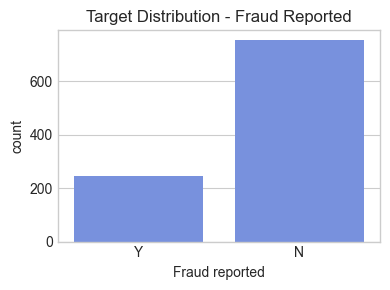

In [42]:
target_counts = claim_data_cleaned['fraud_reported'].value_counts()

print('Percentage:', (claim_data_cleaned['fraud_reported'].value_counts(normalize = True) * 100).round(1).astype(str) +'%')

plt.figure(figsize=(4,3))
sns.countplot(data = claim_data_cleaned, x = 'fraud_reported')
plt.xlabel('Fraud reported')
plt.title('Target Distribution - Fraud Reported')
plt.tight_layout()
plt.savefig( save_dir / 'target_distribution.png')
plt.show()

**Observation**:
- The target classes are imbalanced.
- Approximately **~75%** of claims are labeled as non-fraud (N), while only **~25%** are labeled as fraud (Y).

This imbalance means that *accuracy* is not a reliable metric on its own. In the modeling phase, I will therefore focus on *precision*, *recall*, *F1-scor*e, and *PR-AUC*, and consider imbalance-handling strategies such as *class weighting* (and, if needed, resampling methods like *SMOTE*) within the training pipeline.

### Numerical Features Exploration

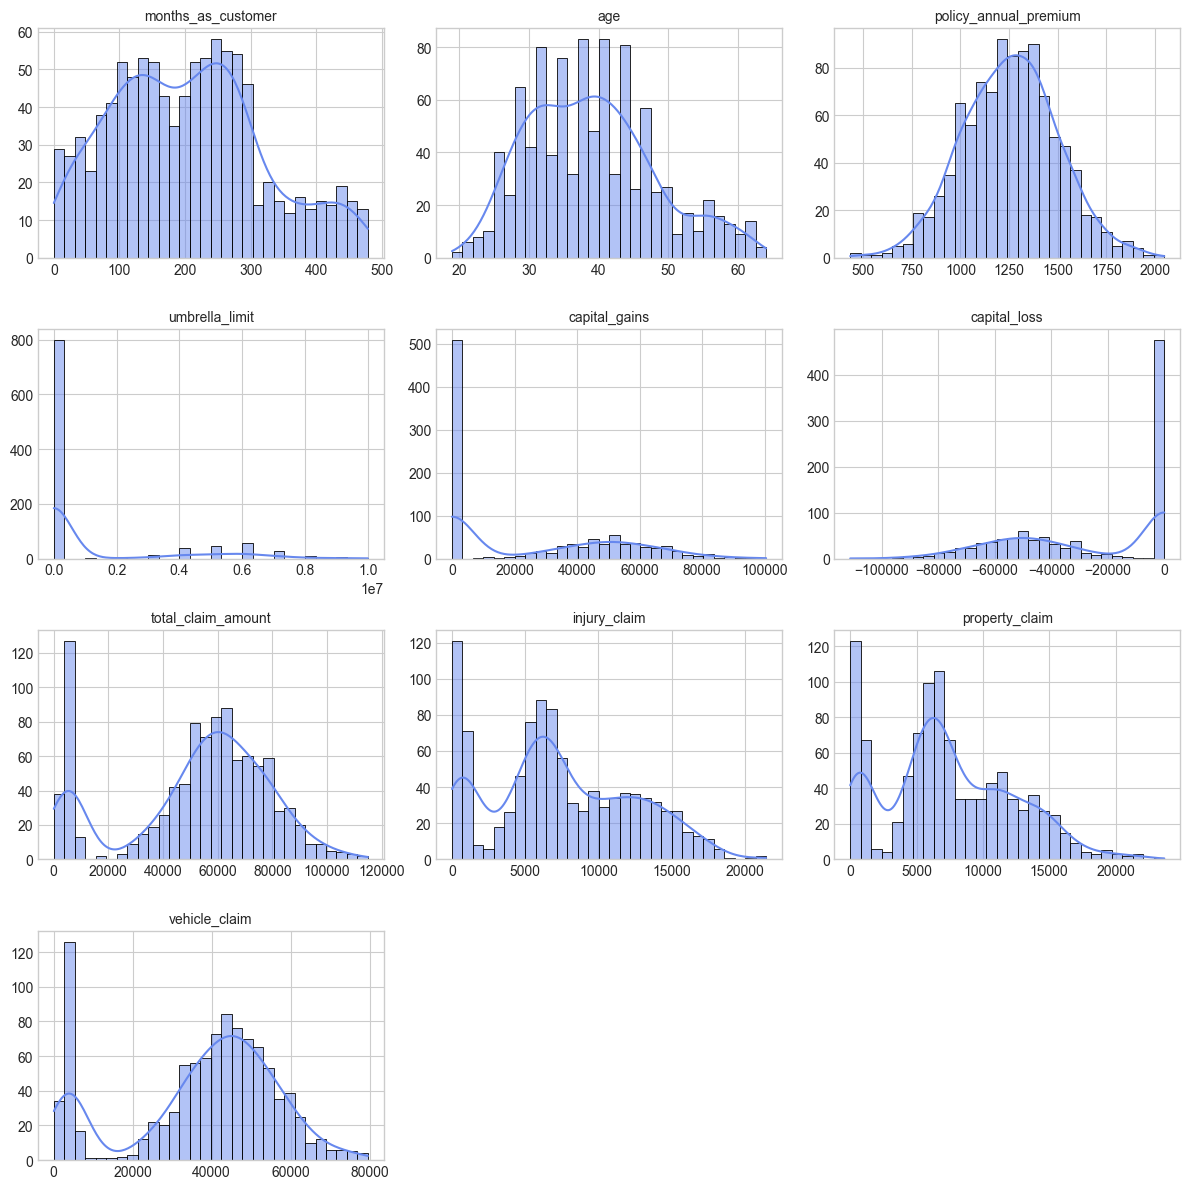

In [43]:
# Histogram Plots

df_plot = claim_data_cleaned.copy()

df_plot = df_plot.drop(['auto_year', 'policy_number', 'insured_zip',], axis = 1)


num_cols = df_plot.select_dtypes(include=['int64','float64']).columns.tolist()
if "fraud_reported" in num_cols: 
    num_cols.remove("fraud_reported")
    
    
discrete_num = ['policy_deductable', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'incident_hour_of_the_day']
discrete_num = [c for c in discrete_num if c in df_plot.columns]

continuous_num = [c for c in num_cols if c not in discrete_num]

# Plot
cols = 3
rows = (len(continuous_num) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()

for ax, col in zip(axes, continuous_num):
    sns.histplot(data = df_plot, x = col, bins = 30, kde = True, ax = ax)
    ax.set_title(col, fontsize = 10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
for ax in axes[len(continuous_num):]:
    ax.set_visible(False)
    
plt.tight_layout()
plt.savefig(save_dir / 'num_hist_continuous.png') 
plt.show()

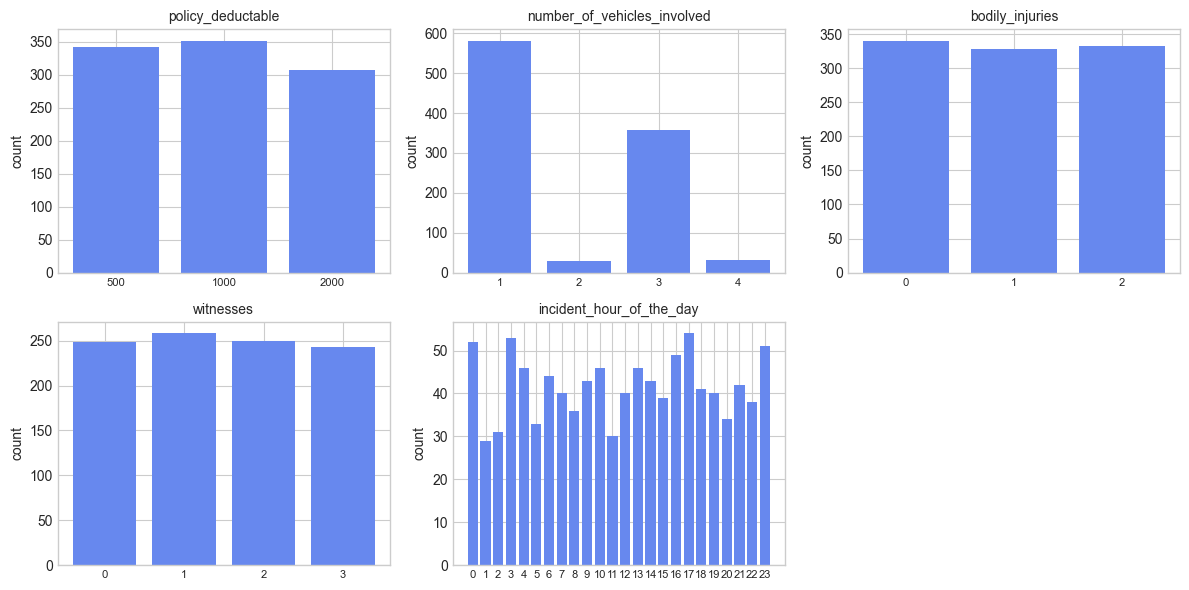

In [44]:
cols = 3
rows = (len(discrete_num) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()

for ax, col in zip(axes, discrete_num):
    vc = df_plot[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('count')
    ax.tick_params(axis = 'x', labelrotation = 0, labelsize = 8)

for ax in axes[len(discrete_num):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(save_dir / 'num_hist_discrete.png', dpi=200)
plt.show()

**Observation (continuous numeric)**: Several continuous variables are right-skewed and contain outliers (e.g., claim amounts and umbrella_limit). `capital_gains` and `capital_loss` show strong zero-inflation.<br>

**Observation (discrete numeric)**: Some numerical variables take only a small set of values (e.g., deductibles and count-based variables like `witnesses` and `bodily_injuries`). I therefore treat them as discrete distributions rather than continuous variables.

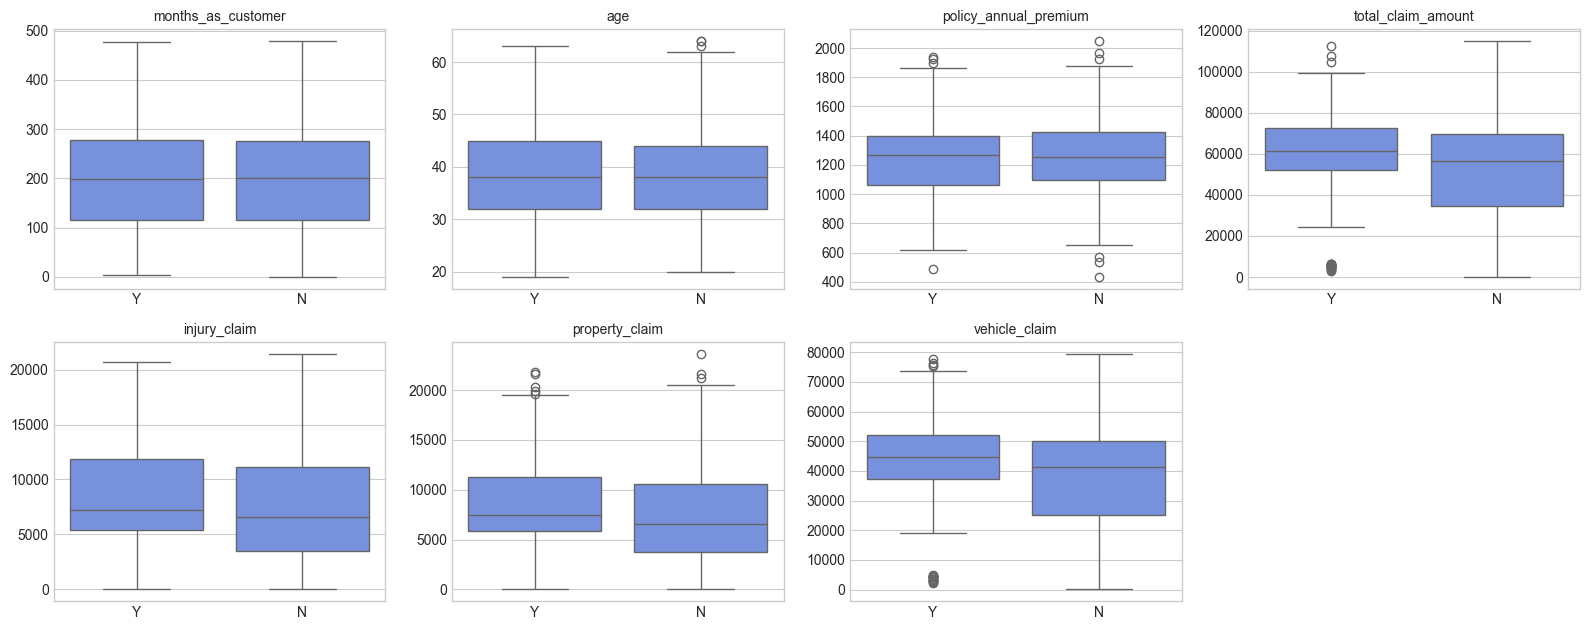

In [45]:
box_cols = [
    'months_as_customer',
    'age',
    'policy_annual_premium',
    'total_claim_amount',
    'injury_claim',
    'property_claim',
    'vehicle_claim'
]
box_cols = [c for c in box_cols if c in df_plot.columns]

cols = 4
rows = (len(box_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.2*rows))
axes = axes.flatten()

for ax, col in zip(axes, box_cols):
    sns.boxplot(data = df_plot, x = 'fraud_reported', y = col, ax = ax, showfliers = True)
    ax.set_title(col, fontsize = 10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
for ax in axes[len(box_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(save_dir / 'boxplots_continuous_by_target.png')
plt.show()

**Observation (boxplots by target)**:<br>
The boxplots compare the distribution of key continuous numerical features between fraudulent (Y) and non-fraudulent (N) claims. Claim-related variables (`total_claim_amount`, `vehicle_claim`, `property_claim`, `injury_claim`) show visible shifts in their distributions and higher upper ranges for fraud cases, suggesting potential predictive value. In contrast, demographic and policy-related variables such as age, `months_as_customer`, and `policy_annual_premium` show smaller differences between classes. Outliers are present across most claim variables, which is expected in insurance data and motivates robust modeling choices.

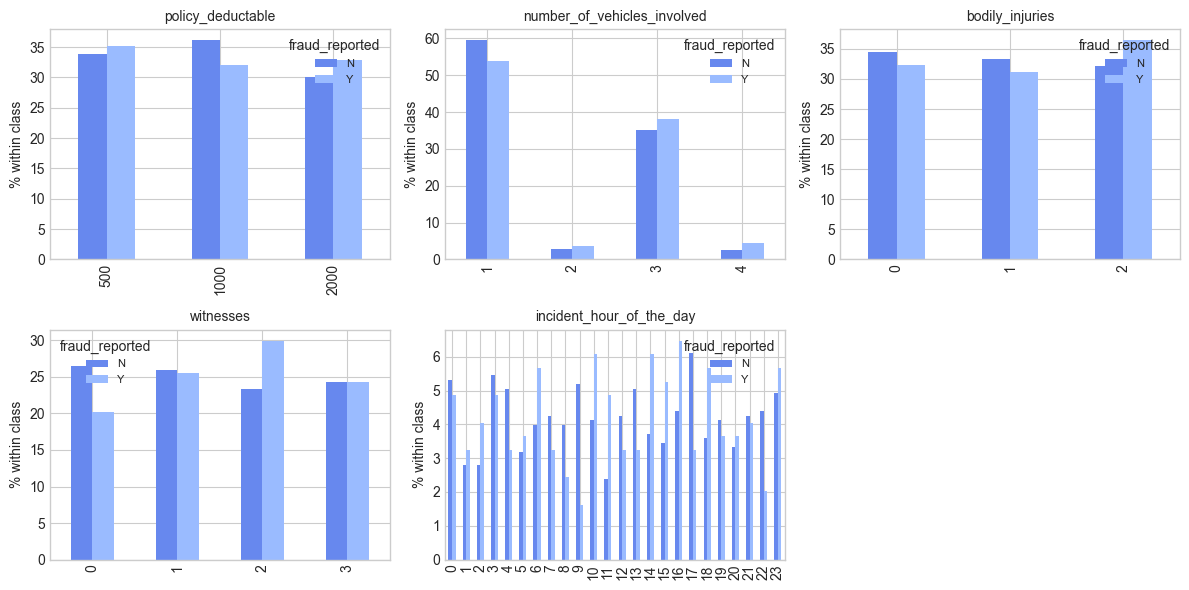

In [46]:
discrete_cols = [
    'policy_deductable',
    'number_of_vehicles_involved',
    'bodily_injuries',
    'witnesses',
    'incident_hour_of_the_day'
]
discrete_cols = [c for c in discrete_cols if c in df_plot.columns]
discrete_cols

cols = 3
rows = (len(discrete_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = axes.flatten()

for ax, col in zip(axes, discrete_cols):
    prop = pd.crosstab(df_plot[col], df_plot['fraud_reported'], normalize = 'columns') * 100
    prop.plot(kind='bar', ax = ax)
    ax.set_title(col, fontsize = 10)
    ax.set_xlabel('')
    ax.set_ylabel('% within class')
    ax.legend(title='fraud_reported', fontsize = 8)

for ax in axes[len(discrete_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(save_dir / 'discrete_num_by_target.png')
plt.show()


**Observation (discrete numerical features)**:<br>
I compared the class-conditional distributions for discrete numerical variables using proportional bar charts. Overall, the distributions for fraud (Y) and non-fraud (N) are quite similar across most levels, suggesting limited standalone predictive power. A small difference appears for `witnesses` and `number_of_vehicles_involved`, but the effect is modest and should be interpreted cautiously.

#### Statistical Test - Numerical features

In [47]:
data_test = claim_data_cleaned.drop(['policy_number', 'insured_zip'], axis = 1)
num_cols = data_test.select_dtypes(include = ['int64', 'float64']).columns.tolist()
if 'fraud_reported' in num_cols:
    num_cols.remove('fraud_reported')


def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    greater = sum((xi > y).sum() for xi in x)
    lesser  = sum((xi < y).sum() for xi in x)
    return (greater - lesser) / (nx * ny)

g0 = data_test[data_test['fraud_reported'] == 'N']
g1 = data_test[data_test['fraud_reported'] == 'Y']

mw_rows = []
for col in num_cols:
    x, y = g0[col].dropna().values, g1[col].dropna().values
    
    if (len(x) < 5) or (len(y) < 5):
        continue
        
    stat, p = mannwhitneyu(x, y, alternative = 'two-sided')
    delta = cliffs_delta(y, x)
    
    mw_rows.append({
        'feature': col,
        'p_value': p,
        'cliffs_delta': delta,
        'median_N': np.median(x),
        'median_Y': np.median(y),
        'n_N': len(x),
        'n_Y': len(y)
    })
    
mw_results = pd.DataFrame(mw_rows)

mw_results = mw_results.sort_values(['cliffs_delta', 'p_value'], ascending=[False, True])

In [48]:
mw_results

,feature,p_value,cliffs_delta,median_N,median_Y,n_N,n_Y
14,vehicle_claim,0.000006,0.191864,41220.00,44800.00,753,247
11,total_claim_amount,0.000011,0.186434,56520.00,61290.00,753,247
13,property_claim,0.000024,0.178724,6560.00,7440.00,753,247
12,injury_claim,0.005498,0.117597,6620.00,7240.00,753,247
10,witnesses,0.114650,0.064702,1.00,2.00,753,247
8,number_of_vehicles_involved,0.103105,0.060110,1.00,1.00,753,247
4,umbrella_limit,0.067208,0.054352,0.00,0.00,753,247
9,bodily_injuries,0.285335,0.042669,1.00,1.00,753,247
0,months_as_customer,0.632518,0.020259,200.00,199.00,753,247
15,auto_year,0.789654,0.011291,2005.00,2006.00,753,247


**Statistical Test Results:**

I compared the distributions of numerical features between non-fraud (N) and fraud (Y) claims using the Mann–Whitney U test and Cliff’s delta as an effect size. The clearest differences appear in claim-related variables (`vehicle_claim`, `total_claim_amount`, `property_claim`, and `injury_claim`). For these features, the medians are higher in fraud cases, meaning that a “typical” fraud claim tends to involve higher claim amounts than a typical non-fraud claim.<br>
The effect sizes for these claim variables are small-to-moderate, while most other numerical features (e.g., `age`, `policy_deductable`, `incident_hour_of_the_day`, `months_as_customer`) show near-zero effect sizes and very similar medians across classes.<br> 
Overall, this suggests that claim amounts are among the strongest numerical indicators in this dataset, whereas many demographic or policy-related variables have limited standalone discriminatory power.

### Categorical Features Exploration

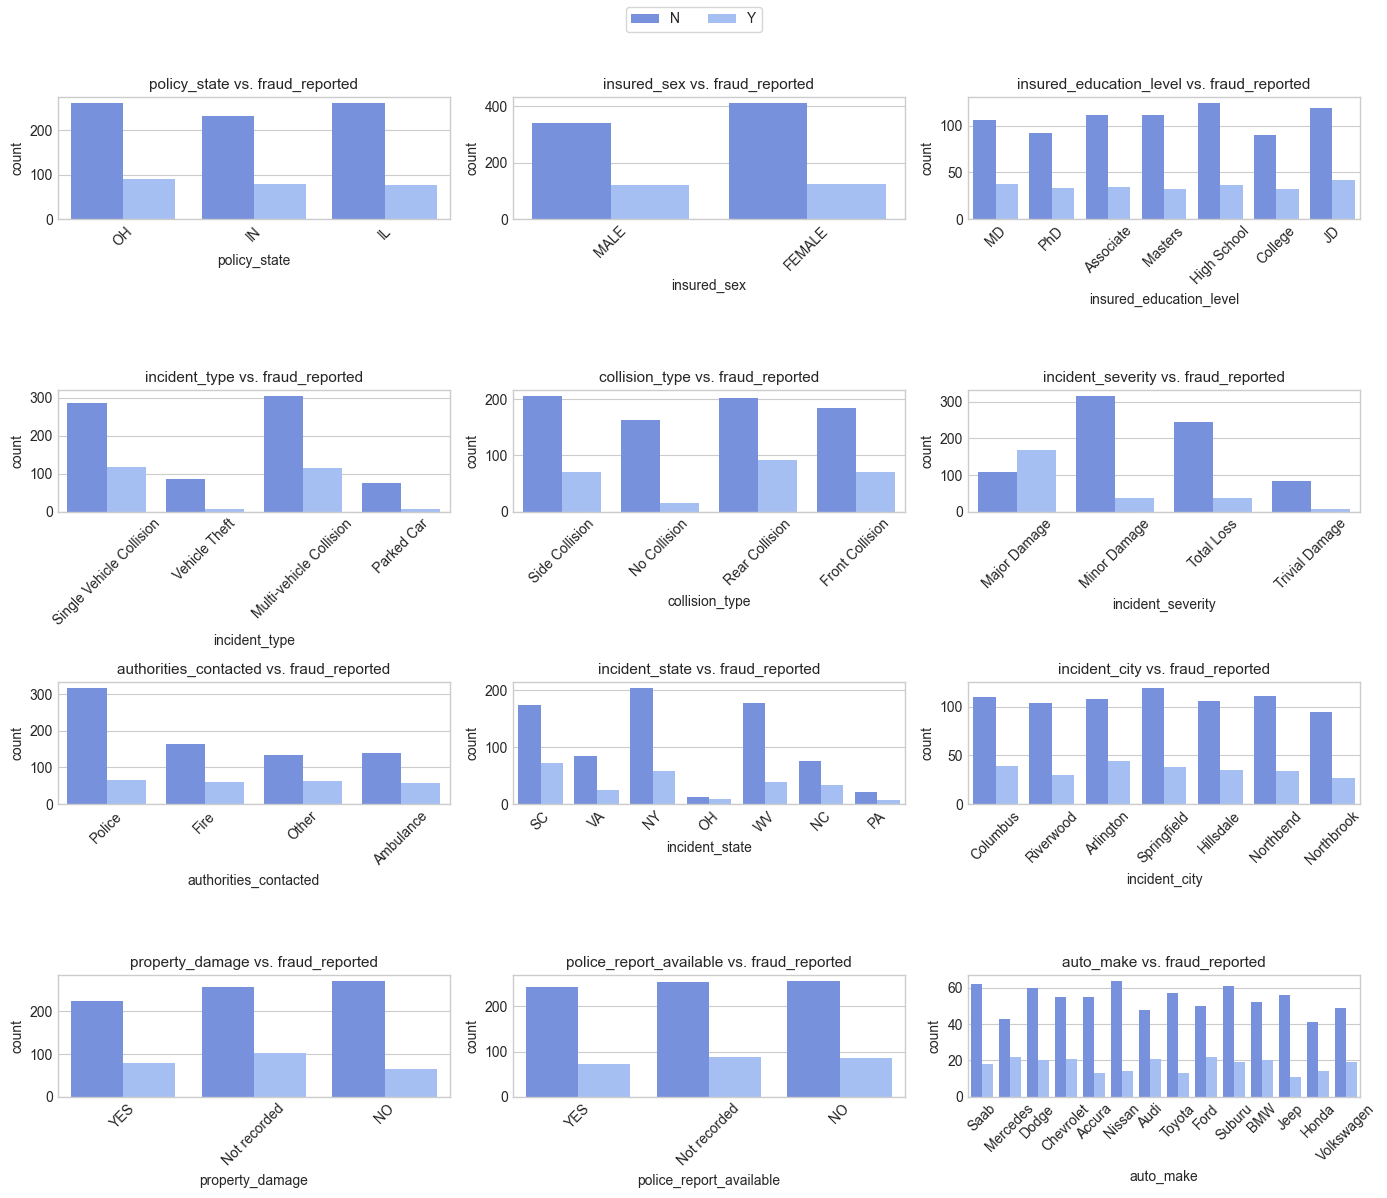

In [49]:
drop_cols = ['incident_date', 'insured_relationship', 'incident_location',
    'auto_model', 'insured_occupation', 'insured_hobbies', 'policy_csl', 'policy_bind_date'
            ]
claim_cat_cols = claim_data_cleaned.drop(columns = drop_cols)

cat_cols = claim_cat_cols.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'fraud_reported']

rows, cols = 4, 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 12))
axes = axes.flatten()

handles, labels = None, None

for ax, col in zip(axes, cat_cols):
    sns.countplot(data = claim_cat_cols, x = col, hue = 'fraud_reported',
                  ax=ax, hue_order = ['N','Y']
                  )
    ax.set_title(f'{col} vs. fraud_reported', fontsize = 11)
    ax.tick_params(axis = 'x', rotation = 45)
    if handles is None and ax.get_legend():
        handles, labels = ax.get_legend_handles_labels()
    if ax.get_legend():
        ax.get_legend().remove()

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

if handles:
    fig.legend(handles, labels, loc = 'upper center', ncol = 2, frameon = True)

plt.tight_layout(rect = [0, 0, 1, 0.95])
plt.savefig(save_dir / 'categorical_features_fraud.png', dpi = 200)
plt.show()

**Categorical Feature Distribution by Fraud Status**<br>

The categorical count plots show the distribution of fraud_reported across levels of each categorical feature. Because the target is imbalanced, these plots primarily highlight which categories are most common overall.<br>

Some features such as `incident_severity`, `incident_type`, and `authorities_contacted` show visible differences in the class distribution across categories, suggesting they may carry predictive signal. However, to assess whether a category is truly associated with fraud, it is more informative to compare fraud rates (proportions) rather than raw counts.


Fraud appears relatively more represented in some levels of `incident_severity` and `incident_type` (e.g., ‘Major Damage’, collision-related incident types), but this should be confirmed using fraud-rate plots or statistical tests.

#### Statistical Test - Categorical features

In [50]:
def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.to_numpy().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / min(k-1, r-1))

chi_rows = []
for col in cat_cols:
    ct = pd.crosstab(claim_cat_cols[col], claim_cat_cols['fraud_reported'])
    
    if ct.shape[0] < 2:
        continue
    
    chi2, p, dof, exp = chi2_contingency(ct)
    
    chi_rows.append({
        'feature': col,
        'p_value': p,
        'cramers_v': cramers_v(ct)
    })

chi2_results = pd.DataFrame(chi_rows).sort_values(['cramers_v', 'p_value'], ascending = [False, True])

chi2_results['p_value'] = chi2_results['p_value'].map(lambda v: f'{v:.3g}')
chi2_results['cramers_v'] = chi2_results['cramers_v'].round(3)

chi2_results

,feature,p_value,cramers_v
5,incident_severity,5.45e-57,0.514
4,collision_type,7.12e-07,0.177
3,incident_type,2.1e-06,0.171
6,authorities_contacted,0.000316,0.137
7,incident_state,0.0131,0.127
11,auto_make,0.39,0.117
9,property_damage,0.018,0.090
8,incident_city,0.856,0.051
2,insured_education_level,0.946,0.041
0,policy_state,0.6,0.032


**Statistical Test Results**

The *chi-square* tests indicate that several incident-related categorical variables are associated with fraud_reported. The strongest relationship is observed for `incident_severity` (Cramér’s V = 0.514, p ≪ 0.001), indicating a substantial dependence between severity levels and fraud occurrence.<br>

`collision_type` (V = 0.177) and `incident_type` (V = 0.171) show smaller but still statistically significant associations, suggesting these incident characteristics may carry useful signal. `authorities_contacted` (V = 0.137) and `incident_state` (V = 0.127) exhibit weaker yet significant relationships, while `property_damage` shows only a small effect (V = 0.090).<br>

In contrast, variables such as `insured_sex`, `insured_education_level`, `policy_state`, `police_report_available`, and `incident_city` show no statistically significant association with fraud in this dataset (p > 0.05). Overall, incident-related and claim-context features appear to be the most informative categorical variables for fraud detection.

In [51]:
mw_results.to_csv(save_art / 'mannwhitney_cliffs.csv', index = False)
chi2_results.to_csv(save_art / 'chi2_results.csv', index = False)

### Heatmap

C:\Users\adris\AppData\Local\Temp\ipykernel_10456\2153741589.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  claim['fraud_reported'] = claim['fraud_reported'].replace({'Y': 1, 'N': 0})


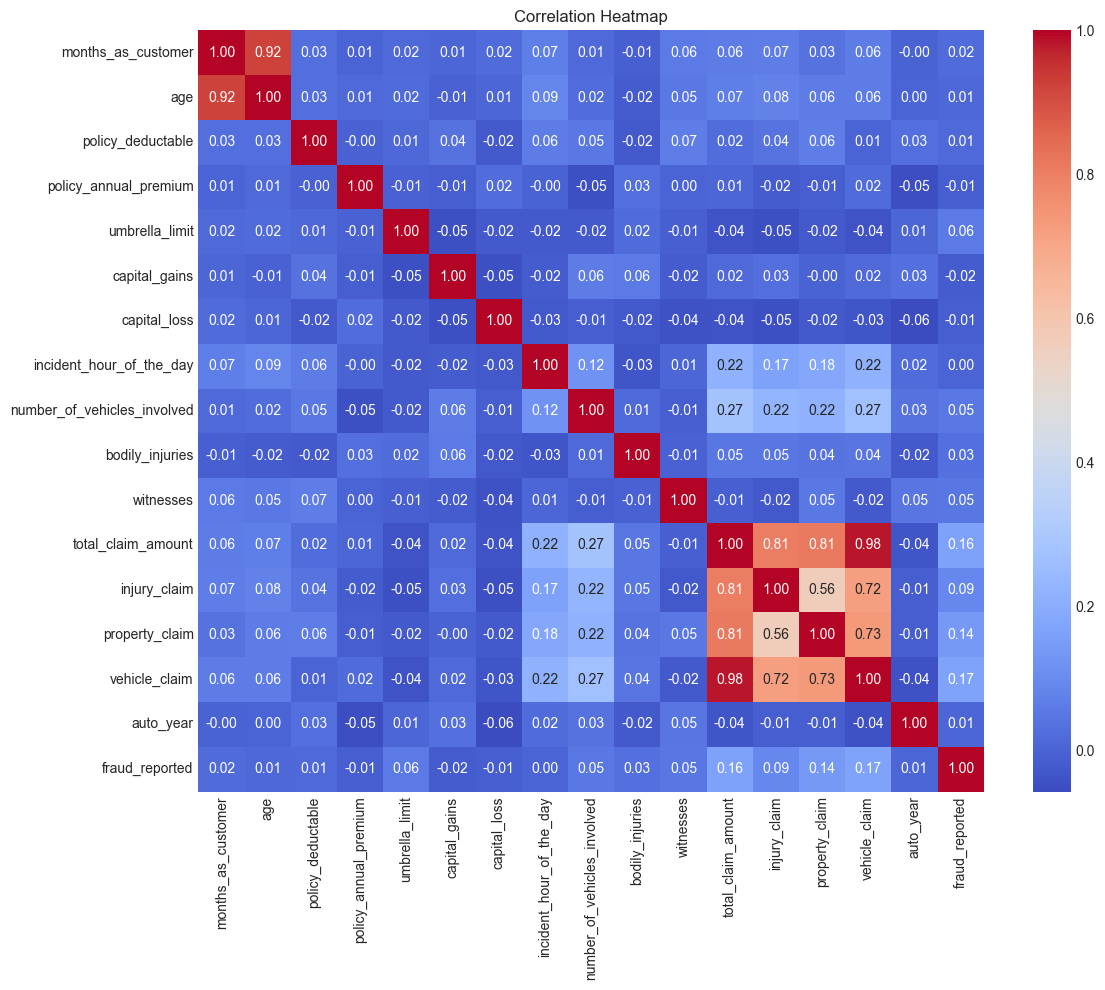

In [52]:
claim = claim_data_cleaned.copy()

claim['fraud_reported'] = claim['fraud_reported'].replace({'Y': 1, 'N': 0})
claim_num = claim.drop(['policy_number', 'insured_zip'], axis = 1).select_dtypes(include = ['int64', 'float'])

corr = claim_num.corr(method = 'pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(save_dir / 'heatmap.png', dpi = 200)
plt.show()

**Observations:**

The correlation Heatmap shows Pearson correlations between numerical features.<br> Including the binary target variable `fraud_reported`. 


- The strongest correlations occur among amount variables.
This is expected because `total_claim_amount` is closely related to its components `vehicle_claim`, `property_claim`, `injury_claim`.<br>
In particular, `total_claim_amount`  correlates very strongly with `vehicle_claim` (0.98) and strongly with `injury_claim` and `property_claim` (both ~0.81), indicating substantial redundancy.
  

- The target variable `fraud_reported` shows only *weak linear correlations* with individual features (e.g., `vehicle_claim` ~0.17, `total_claim_amount` ~0.16, `property_claim` ~0.14), suggesting that fraud is unlikely to be explained by a single linear relationship.


- `months_as_customer` and `age` are highly correlated (0.92), This may affect coefficient stability in linear models, while tree-based models are generally less sensitive.

# 🧠 Claim Prediction - Data Preprocessing & Feature Engineering

## 1. Feature Cleaning / Selection

### Feature Exploration - Fraud Rate & Claims per Month

In [53]:
claim_data_fe = claim_data_cleaned.copy()

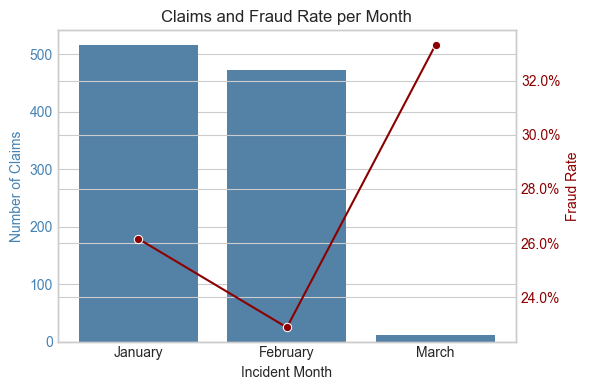

In [54]:
# Convert Target Variable 'fraud_reported'

claim_data_fe['fraud_reported'] = claim_data_fe['fraud_reported'].map({'Y': 1, 'N': 0})

claim_data_fe['incident_date'] = pd.to_datetime(claim_data_fe['incident_date'])
claim_data_fe['incident_month'] = claim_data_fe['incident_date'].dt.month

# Prepare aggregated data
monthly_data = claim_data_fe.groupby('incident_month').agg(
    num_claims=('fraud_reported', 'count'),
    fraud_rate=('fraud_reported', 'mean')
).reset_index()

# Rename months
month_mapping = {
    1: 'January',
    2: 'February',
    3: 'March'
}
monthly_data['incident_month'] = monthly_data['incident_month'].map(month_mapping)
month_order = ['January', 'February', 'March']

# Plot
fig, ax1 = plt.subplots(figsize=(6, 4))

# Total claims (bar)
sns.barplot(x = 'incident_month', y = 'num_claims', data = monthly_data, color = 'steelblue', ax=ax1, order = month_order)
ax1.set_xlabel('Incident Month')
ax1.set_ylabel('Number of Claims', color = 'steelblue')
ax1.tick_params(axis = 'y', labelcolor = 'steelblue')

# Fraud rate (line)
ax2 = ax1.twinx()
sns.lineplot(x='incident_month', y = 'fraud_rate', data = monthly_data, color = 'darkred', marker = 'o', ax = ax2)
ax2.set_ylabel('Fraud Rate', color = 'darkred')
ax2.tick_params(axis = 'y', labelcolor = 'darkred')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title('Claims and Fraud Rate per Month')
plt.tight_layout()
plt.savefig(save_dir / 'claim_fraud_month.png', dpi = 200)
plt.show()

In [55]:
monthly_data[['incident_month', 'num_claims', 'fraud_rate']]

,incident_month,num_claims,fraud_rate
0,January,516,0.261628
1,February,472,0.228814
2,March,12,0.333333


**Observations:**

To explore potential seasonality in the claims, I extracted the incident month from the `incident_date` feature and analyzed both the total number of claims and the fraud rate across months.


- The dataset covers only January to March, limiting long-term seasonal insights.
- The highest number of claims occurred in January, followed by February and a much lower number in March.
- The fraud rate varies across the observed months, but given the limited time window, these differences should be interpreted cautiously.

### Feature Exploration - months_as_customer & age

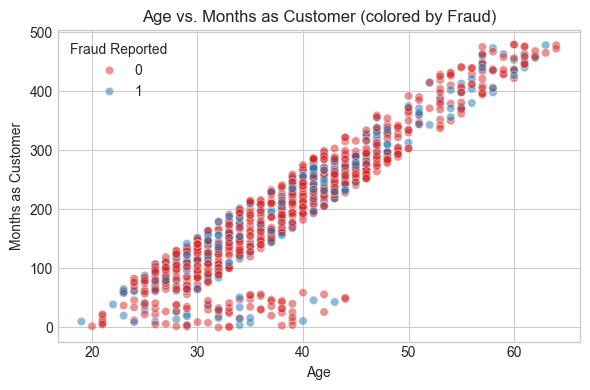

In [56]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data = claim_data_fe,
    x = 'age',
    y = 'months_as_customer',
    hue = 'fraud_reported',
    alpha = 0.5,
    palette = {0: '#d62728', 1: '#1f77b4'}
)

plt.title('Age vs. Months as Customer (colored by Fraud)')
plt.xlabel('Age') 
plt.ylabel('Months as Customer')
plt.legend(title ='Fraud Reported')
plt.tight_layout()
plt.savefig(save_dir / 'age_vs_month_customer.png', dpi = 200)
plt.show() 

**Obersavtions**:

The scatterplot shows a strong linear relationship between `age` and `months_as_customer`, indicating redundancy between both variables.<br> Since age also shows negligible association with fraud in the univariate analysis, I decided to drop age and keep `months_as_customer` as a tenure-related indicator for now.

### Feature Exploration - Claim-related Features

In [57]:
def plot_selected_claims(df, columns=['vehicle_claim', 'injury_claim', 'property_claim'], bins = 30):
    """
    Plot overlaid fraud vs. non-fraud density histograms
    for the specified claim columns.
    """
    for col in columns:
        fraud   = df.loc[df['fraud_reported'] == 1, col]
        nonfraud = df.loc[df['fraud_reported'] == 0, col]

        plt.figure(figsize=(6, 4))
        sns.histplot(nonfraud, bins = bins, color = 'skyblue',
                     label ='Non-Fraud', kde = True, stat = 'density')
        
        sns.histplot(fraud, bins = bins, color = 'salmon',
                     label = 'Fraud', kde = True, stat = 'density')

        plt.title(f'Distribution of {col.replace("_", " ").title()} by Fraud Status')
        plt.xlabel(col.replace('_', ' ').title())
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_dir / f'{col}_fraud.png', dpi = 200)
        plt.show()

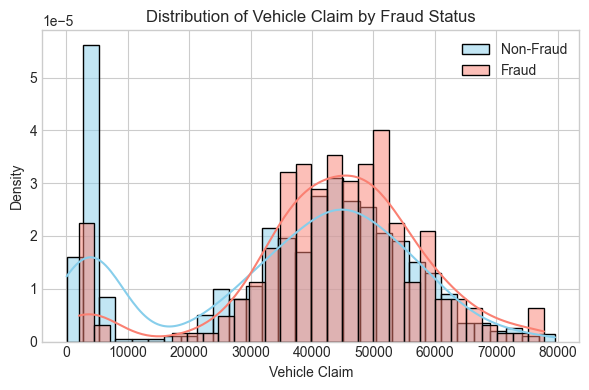

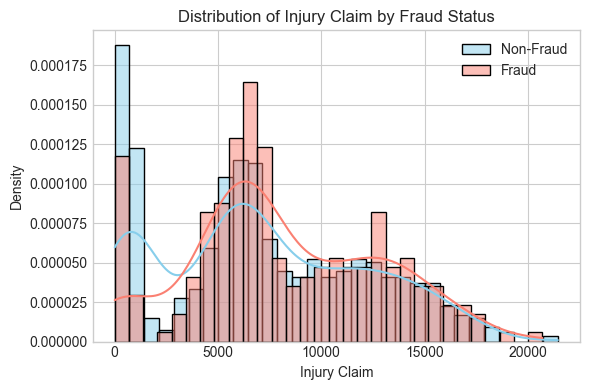

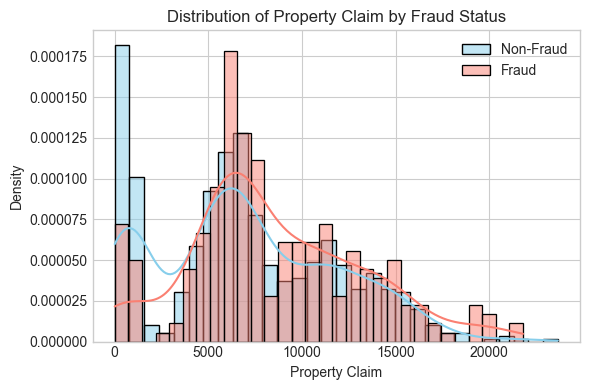

In [58]:
plot_selected_claims(claim_data_fe)

**Claim Amount Distributions by Fraud Status**

I compared the distributions of `vehicle_claim`, `injury_claim`, and `property_claim` between fraud and non-fraud cases using density histograms.<br> Across all three components, fraud cases tend to be shifted towards higher claim amounts, although the distributions still overlap substantially.

- *Vehicle Claim*: Fraudulent cases Fraud cases show a clearer concentration in the mid-to-higher range (roughly ~35k–55k), while non-fraud cases display more mass at very low values and a broader spread.

- *Injury Claim*: Fraud claims are slightly shifted towards higher amounts, but the overlap remains large, indicating limited separation from this feature alone.

- *Property Claim*: Fraud shows a slightly different shape with a higher concentration around mid-range values and a heavier right tail


In [59]:
claim_cols = ['vehicle_claim', 'injury_claim', 'property_claim']
 
fraud_claim_summary = claim_data_fe.groupby('fraud_reported')[claim_cols].mean().T
fraud_claim_summary.columns = ['Non-Fraud', 'Fraud']
fraud_claim_summary['Difference'] = fraud_claim_summary['Fraud'] - fraud_claim_summary['Non-Fraud']
fraud_claim_summary.round(2)

,Non-Fraud,Fraud,Difference
vehicle_claim,36090.49,43533.64,7443.15
injury_claim,7179.23,8208.34,1029.11
property_claim,7018.88,8560.12,1541.24


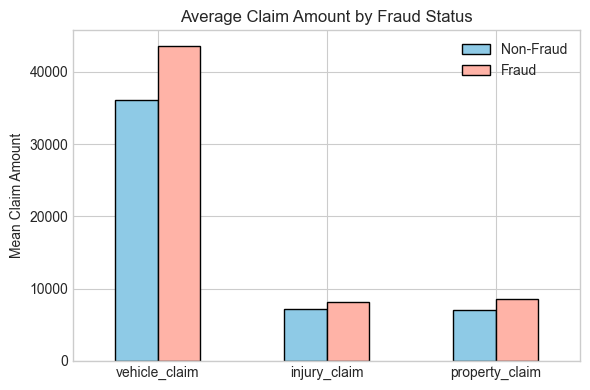

In [60]:
fraud_claim_summary[['Non-Fraud', 'Fraud']].plot(
    kind='bar', figsize=(6,4), 
    color=['#8ecae6','#ffb3a7'], 
    edgecolor='black'
)
plt.title('Average Claim Amount by Fraud Status')
plt.ylabel('Mean Claim Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(save_dir / 'avg_claim_fraud.png', dpi = 200)
plt.show()

The bar chart confirms that fraud cases have higher average claim amounts for all three claim components, especially `vehicle_claim`.<br> 

#### Claim Shares

In [61]:
# Avoid division by zero
claim_data_fe['total_claim_amount_safe'] = claim_data_fe['total_claim_amount'].replace(0, np.nan)

claim_data_fe['injury_share'] = claim_data_fe['injury_claim'] / claim_data_fe['total_claim_amount_safe']
claim_data_fe['vehicle_share'] = claim_data_fe['vehicle_claim'] / claim_data_fe['total_claim_amount_safe']
claim_data_fe['property_share'] = claim_data_fe['property_claim'] / claim_data_fe['total_claim_amount_safe']


# Drop helper
claim_data_fe = claim_data_fe.drop(columns=['total_claim_amount_safe'])


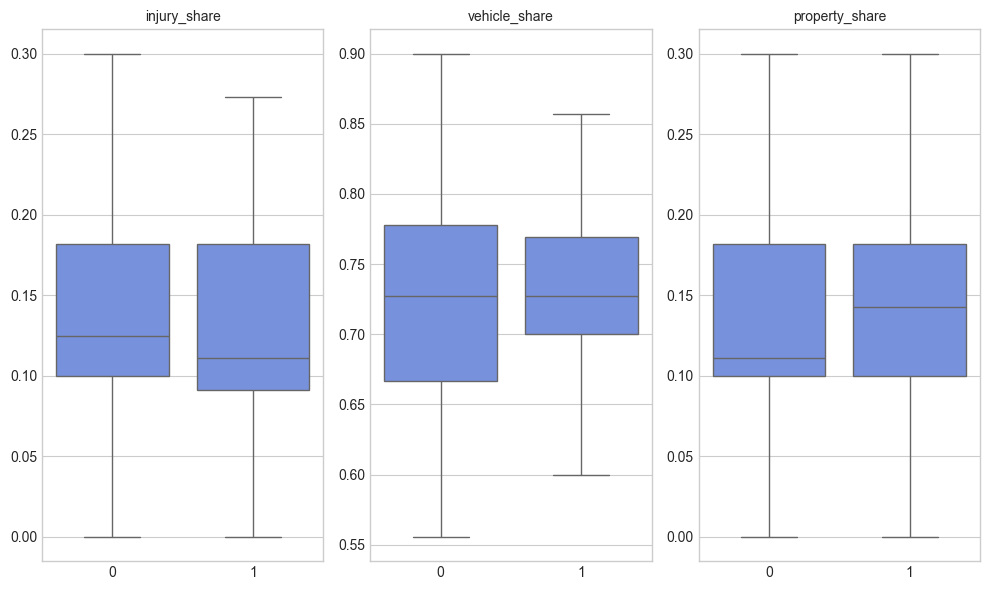

In [62]:
shares = ['injury_share', 'vehicle_share', 'property_share']

fig, axes = plt.subplots(1, 3, figsize=(10,6))
axes = axes.flatten()

for ax, col in zip(axes, shares):
    sns.boxplot(data = claim_data_fe, x = 'fraud_reported', y = col, ax = ax, showfliers = False)
    ax.set_title(col, fontsize = 10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(save_dir / 'claim_composition_shares_boxplot.png', dpi = 200)
plt.show()


I engineered claim composition features to capture how the total claim amount is distributed across components.<br> Specifically, I computed the shares of `injury_claim`, `vehicle_claim`, and `property_claim` relative to `total_claim_amount`.<br> These normalized features can highlight differences in claim structure that may not be visible when looking only at absolute amounts.


The claim composition shares show weaker differences overall. `property_share` appears slightly higher for fraud cases, while `injury_share` is slightly lower and `vehicle_share` shows little change. These share features may still add value in combination with claim size information, but they are not strong standalone separators.

#### Claim Size Relative to Policy Costs

In [63]:
claim_data_fe['claim_to_premium'] = claim_data_fe['total_claim_amount'] / claim_data_fe['policy_annual_premium'].replace(0, np.nan)
claim_data_fe['claim_to_deductible'] = claim_data_fe['total_claim_amount'] / claim_data_fe['policy_deductable'].replace(0, np.nan)

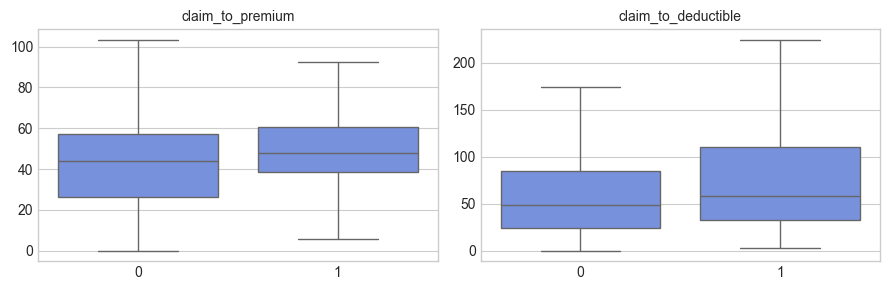

In [64]:
ratio_cols = ['claim_to_premium', 'claim_to_deductible']

fig, axes = plt.subplots(1, 2, figsize=(9,3))
axes = axes.flatten()

for ax, col in zip(axes, ratio_cols):
    sns.boxplot(data = claim_data_fe, x = 'fraud_reported', y = col, ax = ax, showfliers = False)
    ax.set_title(col, fontsize = 10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(save_dir / 'claim_ratio_features_boxplot.png', dpi = 200)
plt.show()


To make claim sizes comparable across customers with different policy costs, I engineered ratio-based features that express the total claim amount relative to the policy’s annual premium and deductible.<br> These ratios capture whether a claim is disproportionately large compared to the contract’s cost structure and may highlight suspicious claims that are not obvious from absolute claim amounts alone.



The ratio-based features show a clearer separation between fraud and non-fraud cases than most raw numerical variables.<br> In particular, both `claim_to_premium` and `claim_to_deductible` tend to be higher for fraudulent claims, suggesting that fraud cases are more often associated with claims that are disproportionately large relative to the policy’s cost structure.

### Feature Exploration - Witnesses

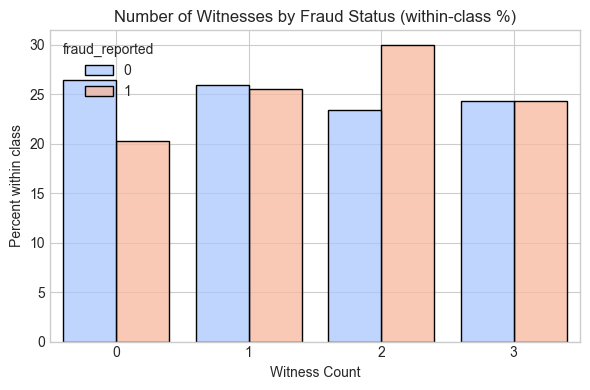

In [65]:
plt.figure(figsize=(6,4))
ax = sns.histplot(
    data = claim_data_fe, 
    x = 'witnesses', 
    hue = 'fraud_reported', 
    stat = 'percent',
    common_norm = False,
    multiple = 'dodge',
    discrete = True,
    shrink = 0.8,
    palette = 'coolwarm', 
    edgecolor = 'black'
)
plt.title('Number of Witnesses by Fraud Status (within-class %)')
plt.xlabel('Witness Count')
plt.ylabel('Percent within class')

ax.set_xticks([0, 1, 2, 3])
ax.set_xlim(-0.5, 3.5)

plt.tight_layout()
plt.savefig(save_dir / 'witnesses_fraud.png', dpi = 200)
plt.show()

I plotted the distribution of witnesses as within-class percentages to account for class imbalance.<br> Fraud cases show a higher proportion of claims with 2 witnesses, while non-fraud cases are slightly more concentrated at 0 witnesses.<br> Overall, the differences are modest, suggesting that witnesses may add weak signal but is unlikely to be a strong standalone predictor.

### Feature Exploration - Time-based Features

#### Incident Hour

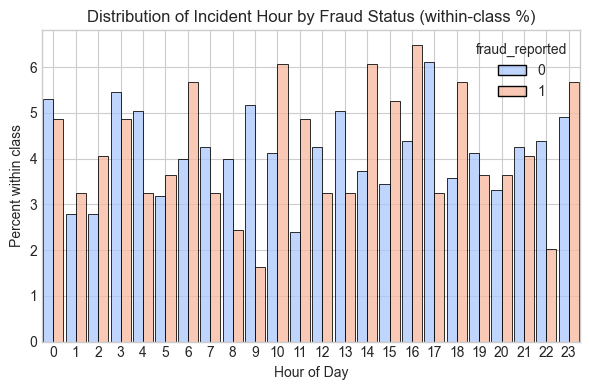

In [66]:
plt.figure(figsize=(6,4))
ax = sns.histplot(
    data = claim_data_fe, 
    x = 'incident_hour_of_the_day', 
    hue = 'fraud_reported', 
    multiple = 'dodge', 
    discrete = True,
    stat = 'percent',
    common_norm = False,
    palette = 'coolwarm',
    edgecolor = 'black',
    shrink = 0.9
)
plt.title('Distribution of Incident Hour by Fraud Status (within-class %)')
plt.xlabel('Hour of Day')
plt.ylabel('Percent within class')

ax.set_xticks(range(0, 24))
ax.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.savefig(save_dir / 'incident_hour_fraud_percent.png', dpi = 200)
plt.show()

I compared the distribution of `incident_hour_of_the_day` between fraud and non-fraud cases using within-class percentages.<br> The hourly patterns are broadly similar, suggesting that incident hour provides limited standalone signal.<br> Some minor differences appear at specific hours (e.g., slightly higher fraud proportions around the afternoon and late evening), but these deviations are small and should be interpreted cautiously.

#### Day of the week and Weekend

In [67]:
claim_data_fe['incident_date']

0     2015-01-25
1     2015-01-21
2     2015-02-22
3     2015-01-10
4     2015-02-17
         ...    
995   2015-02-22
996   2015-01-24
997   2015-01-23
998   2015-02-26
999   2015-02-26
Name: incident_date, Length: 1000, dtype: datetime64[ns]

In [68]:
df_time = claim_data_fe.copy()

df_time['incident_date'] = pd.to_datetime(df_time['incident_date'])
df_time['incident_dayofweek'] = df_time['incident_date'].dt.day_name()
df_time['is_weekend'] = df_time['incident_date'].dt.weekday.isin([5, 6]).astype(int)


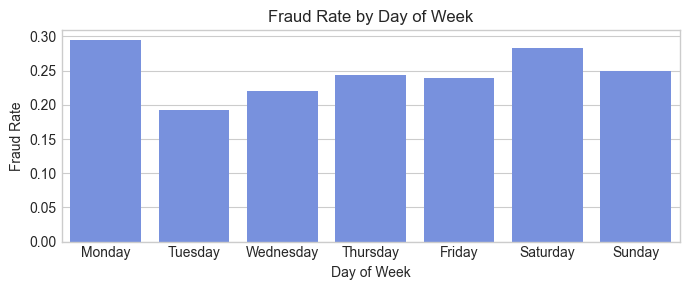

In [69]:
# Fraud Rate by Day of Week

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_rate = (
    df_time.groupby('incident_dayofweek')['fraud_reported']
    .mean()
    .reindex(dow_order)
    .reset_index()
)

plt.figure(figsize=(7,3))
sns.barplot(data = dow_rate, x = 'incident_dayofweek', y = 'fraud_reported')
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.savefig(save_dir / 'fraud_rate_by_weekday.png', dpi = 200)
plt.show()


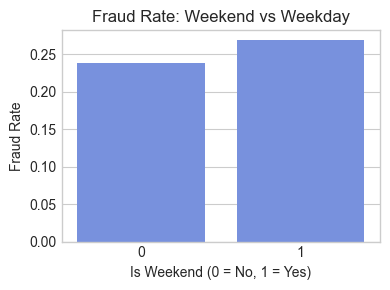

In [70]:
# Weekend vs. Weekday (Fraud Rate)

weekend_rate = df_time.groupby('is_weekend')['fraud_reported'].mean().reset_index()

plt.figure(figsize=(4,3))
sns.barplot(data = weekend_rate, x = 'is_weekend', y = 'fraud_reported')
plt.title('Fraud Rate: Weekend vs Weekday')
plt.xlabel('Is Weekend (0 = No, 1 = Yes)')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.savefig(save_dir / 'fraud_rate_weekend.png', dpi = 200)
plt.show()


I explored time-based features derived from `incident_date` (day of week and weekend indicator) to check whether fraud likelihood differs by timing patterns.<br> 
While minor differences appear in the observed fraud rates, the dataset only covers three months, making these patterns unreliable and potentially driven by sampling noise. To avoid unnecessary feature inflation, I decided not to include these time-based variables in the final feature set.

### Feature Exploration - Vehicles involved

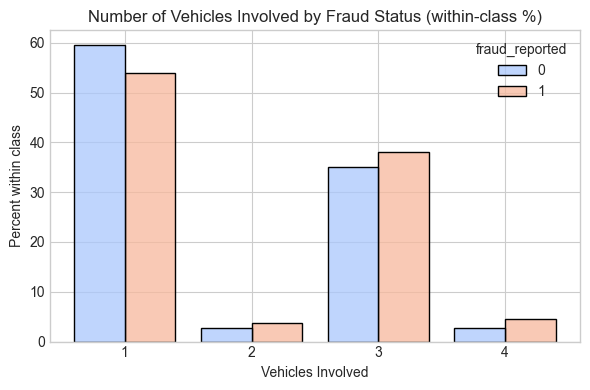

In [71]:
plt.figure(figsize=(6,4))
ax = sns.histplot(
    data = claim_data_fe,
    x = 'number_of_vehicles_involved',
    hue = 'fraud_reported',
    multiple = 'dodge',
    stat = 'percent',
    common_norm = False,
    discrete = True,
    palette = 'coolwarm',
    edgecolor = 'black',
    shrink = 0.8
)

plt.title('Number of Vehicles Involved by Fraud Status (within-class %)')
plt.xlabel('Vehicles Involved')
plt.ylabel('Percent within class')


ax.set_xticks(sorted(claim_data_fe['number_of_vehicles_involved'].unique()))

plt.tight_layout()
plt.savefig(save_dir / 'vehicles_fraud_percent.png', dpi = 200)
plt.show()

I examined `number_of_vehicles_involved` using within-class percentages to account for class imbalance.<br> Fraud cases show a slightly lower proportion of single-vehicle incidents and a higher proportion of claims involving three or more vehicles compared to non-fraud cases.<br> This suggests a modest association, where more complex multi-vehicle situations may be linked to increased fraud likelihood, although the differences are not large.

### Feature Exploration - Umbrella Insurance

The variable `umbrella_limit` represents an additional insurance (a secondary liability protection layer).<br>
Even though it was not statistically significant in isolation, it may still capture behavioral financial differences that contribute fraud risk when combined with other variables.

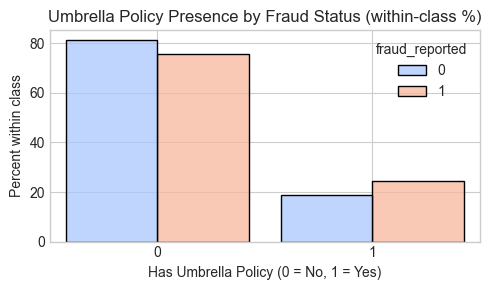

In [72]:
# Fraud Distribution by Umbrella Policy
claim_data_test = claim_data_fe.copy()


claim_data_test['has_umbrella'] = (claim_data_test['umbrella_limit'] > 0).astype(int)

claim_data_test['claim_ratio'] = np.where(
    claim_data_test['umbrella_limit'] > 0,
    (claim_data_test['injury_claim'] + claim_data_test['property_claim'] + claim_data_test['vehicle_claim']) / claim_data_test['umbrella_limit'],
    np.nan
)

plt.figure(figsize=(5,3))
ax = sns.histplot(
    data = claim_data_test,
    x = 'has_umbrella',
    hue = 'fraud_reported',
    multiple = 'dodge',
    discrete = True,
    stat = 'percent',
    common_norm = False,
    palette = 'coolwarm',
    edgecolor = 'black',
    shrink = 0.85
)
plt.title('Umbrella Policy Presence by Fraud Status (within-class %)')
plt.xlabel('Has Umbrella Policy (0 = No, 1 = Yes)')
plt.ylabel('Percent within class')
ax.set_xticks([0, 1])
ax.set_xlim(-0.5, 1.5)
plt.tight_layout()
plt.savefig(save_dir / 'umbrella_policy_dist.png', dpi = 200)
plt.show()


**Umbrella policy presence**

In both classes, most claims come from customers without an umbrella policy. However, the within-class percentages suggest that fraud cases have a slightly higher share of umbrella holders (≈25%) compared to non-fraud cases (≈19%). This could indicate a modest association between having umbrella coverage and fraud occurrence.

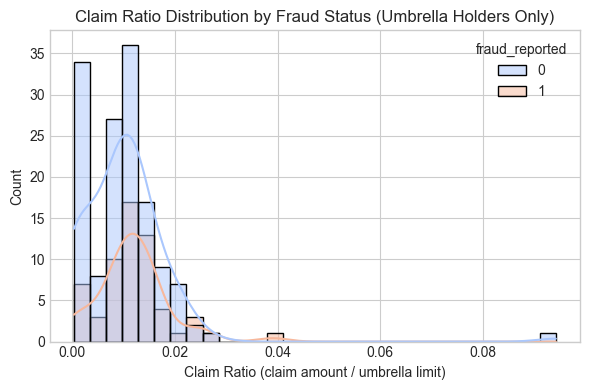

In [73]:
# Claim Ratio distribution by Fraud Status

umbrella_ratio = claim_data_test[
    (claim_data_test['has_umbrella'] == 1) &
    (claim_data_test['claim_ratio'].notna()) &
    (claim_data_test['claim_ratio'] > 0)
]

plt.figure(figsize=(6,4))
sns.histplot(
    data = umbrella_ratio,
    x = 'claim_ratio',
    hue = 'fraud_reported',
    kde = True,
    bins = 30,
    palette = 'coolwarm',
    edgecolor = 'black'
)
plt.title('Claim Ratio Distribution by Fraud Status (Umbrella Holders Only)')
plt.xlabel('Claim Ratio (claim amount / umbrella limit)')
plt.ylabel('Count')

# optional: uncomment if distribution is very skewed
# plt.xscale('log')

plt.tight_layout()
plt.savefig(save_dir / 'claim_ratio_fraud.png', dpi = 200)
plt.show()

**Claim ratio (umbrella holders only)**

The claim_ratio distributions for fraud and non-fraud cases overlap strongly.<br> Fraud cases show a slight shift towards higher ratios and a heavier right tail, but the difference is not large.<br> Overall, claim_ratio may add weak additional signal, but it is unlikely to separate fraud on its own.

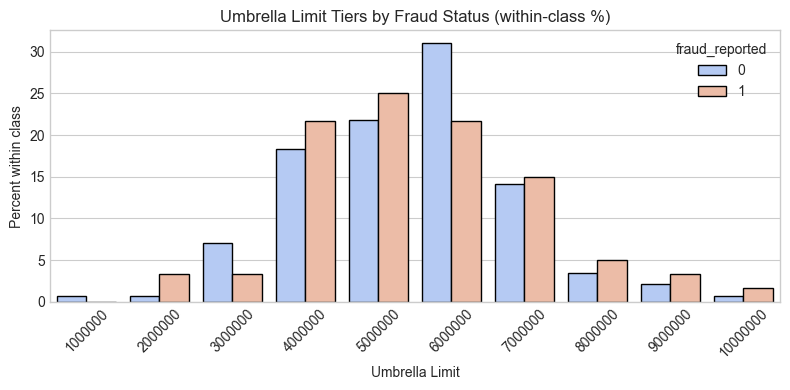

In [74]:
# Umbrelle limit tiers by fraud status

umbrella_tiers = claim_data_test[claim_data_test['umbrella_limit'] > 0].copy()

tier_pct = (
    pd.crosstab(umbrella_tiers['umbrella_limit'], umbrella_tiers['fraud_reported'], normalize='columns')
    * 100
).round(1)

tier_pct = tier_pct.reset_index().melt(id_vars='umbrella_limit', var_name='fraud_reported', value_name='percent')

plt.figure(figsize=(8,4))
sns.barplot(
    data = tier_pct,
    x = 'umbrella_limit',
    y = 'percent',
    hue = 'fraud_reported',
    palette = 'coolwarm',
    edgecolor = 'black'
)

plt.title('Umbrella Limit Tiers by Fraud Status (within-class %)')
plt.xlabel('Umbrella Limit')
plt.ylabel('Percent within class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(save_dir / 'umbrella_limit_tiers_percent.png', dpi = 200)
plt.show()



The umbrella limit values occur in clearly defined coverage tiers rather than as a continuous variable.<br> Using within-class percentages, both fraud and non-fraud cases show very similar distributions across these tiers, with the majority concentrated between 400k and 700k.<br> Fraud cases appear slightly more represented at some higher tiers (e.g., 800k–1M), but the differences are small.<br> Overall, `umbrella_limit` alone provides limited discriminatory signal and is best used in combination with other claim-context features (e.g., claim ratios).

In [75]:
claim_data_fe['has_umbrella_policy'] = (claim_data_fe['umbrella_limit'] > 0).astype(int)


### Feature Drop

In [76]:
claim_data_fe.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital_gains', 'capital_loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', 'incident_month',
       'injury_share', 'vehicle_share', 'property_share', 'claim_to_premium',
       'claim_to_deductible', 'has_umbrella_policy'],
      dtype='object')

Based on the statistical test results and correlation analysis, all features without a significant relationship to fraud will be removed to retain only the most relevant predictors for modeling. 

In [77]:
claim_data_final = claim_data_fe.drop(['policy_number', 'policy_state', 'policy_csl', 'insured_zip', 'incident_location', 
                                       'insured_sex', 'auto_model', 'policy_bind_date', 'insured_education_level', 'insured_occupation',
                                       'insured_hobbies', 'insured_relationship', 'capital_gains', 'capital_loss',
                                       'incident_city', 'incident_state', 'incident_hour_of_the_day', 
                                       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
                                       'police_report_available', 'auto_make', 'auto_year',
                                       'injury_claim', 'property_claim', 'vehicle_claim', 'age', 'incident_date',
                                       'incident_month'], axis = 1)

Based on the EDA and univariate statistical tests, several variables showed weak or inconsistent associations with fraud.<br> Since I want to keep the feature space compact and avoid unnecessary complexity (especially from high-cardinality fields), I removed identifiers, very granular categorical attributes, and variables that did not show meaningful standalone signal in the exploratory analysis.<br> The final feature set focuses on incident context, key claim-size information, and the engineered ratio/composition features.


I removed `incident_state` to reduce the risk of learning location-specific patterns that may not generalise well and to avoid relying on geographic proxies. This keeps the model more robust to distribution shifts and improves interpretability.

In [78]:
claim_data_final.head()

,months_as_customer,policy_deductable,policy_annual_premium,umbrella_limit,incident_type,collision_type,incident_severity,authorities_contacted,property_damage,total_claim_amount,fraud_reported,injury_share,vehicle_share,property_share,claim_to_premium,claim_to_deductible,has_umbrella_policy
0,328,1000,1406.91,0,Single Vehicle Collision,Side Collision,Major Damage,Police,YES,71610,1,0.090909,0.727273,0.181818,50.898778,71.610,0
1,228,2000,1197.22,5000000,Vehicle Theft,No Collision,Minor Damage,Police,Not recorded,5070,1,0.153846,0.692308,0.153846,4.234811,2.535,1
2,134,2000,1413.14,5000000,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NO,34650,0,0.222222,0.666667,0.111111,24.519864,17.325,1
3,256,2000,1415.74,6000000,Single Vehicle Collision,Front Collision,Major Damage,Police,Not recorded,63400,1,0.100000,0.800000,0.100000,44.782234,31.700,1
4,228,1000,1583.91,6000000,Vehicle Theft,No Collision,Minor Damage,Police,NO,6500,0,0.200000,0.700000,0.100000,4.103769,6.500,1


## Outlier Check - final Data

In [79]:
num_cols = claim_data_final.select_dtypes(include = [np.number]).columns.tolist()
print('Numeric Columns:', len(num_cols))

summary = claim_data_final[num_cols].describe(percentiles = [.01, .05, .25, .5, .75, .95, .99]).T
summary = summary.drop(['fraud_reported'], axis = 0)
summary["iqr"] = summary["75%"] - summary["25%"]
summary["range"] = summary["max"] - summary["min"]
display(summary.sort_values("iqr", ascending=False).head(20))

Numeric Columns: 12


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr,range
total_claim_amount,1000.0,5.276194e+04,2.640153e+04,100.000000,2699.400000,4320.000000,41812.500000,58055.000000,70592.500000,8.841300e+04,1.010185e+05,1.149200e+05,28780.000000,1.148200e+05
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.000000,500.000000,500.000000,500.000000,1000.000000,2000.000000,2.000000e+03,2.000000e+03,2.000000e+03,1500.000000,1.500000e+03
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.330000,694.224700,855.112000,1089.607500,1257.200000,1415.695000,1.653443e+03,1.851876e+03,2.047590e+03,326.087500,1.614260e+03
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.000000,4.000000,28.900000,115.750000,199.500000,276.250000,4.290500e+02,4.670100e+02,4.790000e+02,160.500000,4.790000e+02
claim_to_deductible,1000.0,6.254119e+01,4.815994e+01,0.050000,2.143350,3.200000,27.737500,51.435000,90.050000,1.540870e+02,1.883530e+02,2.246400e+02,62.312500,2.245900e+02
claim_to_premium,1000.0,4.377109e+01,2.464188e+01,0.067452,2.080517,3.506767,32.353492,44.975200,58.689165,8.331784e+01,1.032511e+02,1.579881e+02,26.335673,1.579207e+02
vehicle_share,1000.0,7.221119e-01,6.127106e-02,0.555556,0.600000,0.636364,0.692308,0.727273,0.777778,8.181818e-01,8.888889e-01,1.000000e+00,0.085470,4.444444e-01
property_share,1000.0,1.386475e-01,4.864422e-02,0.000000,0.000000,0.090530,0.100000,0.125000,0.181818,2.000000e-01,2.500000e-01,3.333333e-01,0.081818,3.333333e-01
injury_share,1000.0,1.392405e-01,5.066121e-02,0.000000,0.000000,0.083333,0.100000,0.125000,0.181818,2.000000e-01,2.500000e-01,3.000000e-01,0.081818,3.000000e-01
umbrella_limit,1000.0,1.103000e+06,2.296446e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000e+06,8.000000e+06,1.000000e+07,0.000000,1.000000e+07


In [80]:
outlier_summary = []

data_nbs = claim_data_final[num_cols]

for col in num_cols:
    s = data_nbs[col]
    n = len(s)
    if n == 0:
        outlier_summary.append([col, 0, 0.0])
        continue
    
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR == 0:
        outlier_summary.append([col, 0, 0.0])
        continue
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([col, int(outliers), 100 * outliers / n])
    
outlier_df_full = pd.DataFrame(outlier_summary, columns = ['Feature', 'Outliers', 'Percent'])
display(outlier_df_full.sort_values('Percent', ascending = False).head(20))

,Feature,Outliers,Percent
9,claim_to_premium,15,1.5
10,claim_to_deductible,14,1.4
2,policy_annual_premium,9,0.9
7,vehicle_share,4,0.4
8,property_share,1,0.1
4,total_claim_amount,1,0.1
0,months_as_customer,0,0.0
1,policy_deductable,0,0.0
3,umbrella_limit,0,0.0
5,fraud_reported,0,0.0


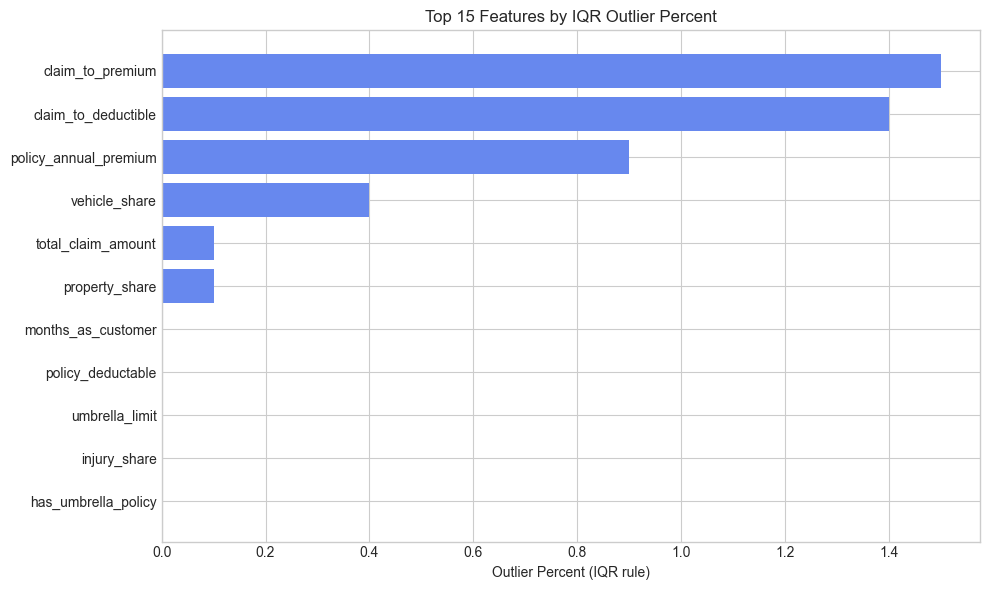

In [81]:
outlier_df_plot = outlier_df_full[outlier_df_full['Feature'] != 'fraud_reported']

top_n = 15
top = outlier_df_plot.sort_values('Percent', ascending=False).head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top['Feature'], top['Percent'])
plt.gca().invert_yaxis()
plt.xlabel('Outlier Percent (IQR rule)')
plt.title(f'Top {top_n} Features by IQR Outlier Percent')
plt.tight_layout()
plt.show()

**Outlier**:

An IQR-based profiling on the final dataset shows a small but noticeable heavy-tail behavior mainly in monetary/ratio features (e.g., claim_to_premium, claim_to_deductible, policy_annual_premium).
We do not remove outliers automatically, since extreme values can carry fraud signal.
Therefore, outlier handling is only considered implicitly via robust scaling for scale-sensitive models (e.g., Logistic Regression), while tree-based models (Random Forest) are unaffected.


**Note**: For discrete, step-wise variables like `umbrella_limit`, the IQR can collapse to zero (Q1 = Q3).<br> In that case, the IQR rule would label every value different from the dominant level as an “outlier”, which reflects category frequency rather than true extreme values.

In [82]:
outlier_df_full.to_csv(save_art / 'IQR_summary.csv', index = False)

In [83]:
data_preprocessed = claim_data_final.copy()

data_preprocessed.to_csv('../data/data_preprocessed.csv', index = False)